In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

pybamm.set_logging_level("WARNING")
print("PyBaMM version:", pybamm.__version__)

PyBaMM version: 26.3.1


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root added to path:", PROJECT_ROOT)

Project root added to path: C:\GitHub\relaxation_diagnostics


In [3]:
from src.relaxation_utils import (
    make_experiment,
    make_model,
    make_base_params,
    make_storage_loss_params,
    detect_rest_start,
    extract_rest_window,
    compute_features,
    compute_all_windows,
    extract_component_rest_window,
    component_summaries,
)

print("Imported relaxation utilities successfully.")

Imported relaxation utilities successfully.


In [5]:
baseline_discharge_min = 20
altered_discharge_min = 30
rest_min = 10

print("Baseline protocol: 1C for", baseline_discharge_min, "min, then rest for", rest_min, "min")
print("Altered protocol:  1C for", altered_discharge_min, "min, then rest for", rest_min, "min")

Baseline protocol: 1C for 20 min, then rest for 10 min
Altered protocol:  1C for 30 min, then rest for 10 min


In [6]:
dense_delta_q_levels = [0.000, 0.025, 0.050, 0.075, 0.100, 0.125, 0.150, 0.175, 0.200]
dense_delta_q_levels

[0.0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]

In [7]:
def run_dense_feature_sweep(discharge_min, rest_min, protocol_name):
    rows = []

    experiment = make_experiment(discharge_min=discharge_min, rest_min=rest_min)

    for delta_q in dense_delta_q_levels:
        sim = pybamm.Simulation(
            make_model(),
            parameter_values=make_storage_loss_params(delta_q),
            experiment=experiment,
        )
        sol = sim.solve()

        rest_t, rest_V, rest_start = extract_rest_window(sol, 120)

        feat = compute_all_windows(rest_t, rest_V)
        feat["label"] = f"{protocol_name}_storage_loss_{delta_q:.3f}Ah"
        feat["delta_q_ah"] = delta_q
        feat["protocol"] = protocol_name
        rows.append(feat)

    return pd.concat(rows, ignore_index=True)

In [8]:
def run_dense_feature_sweep(discharge_min, rest_min, protocol_name):
    rows = []

    experiment = make_experiment(discharge_min=discharge_min, rest_min=rest_min)

    for delta_q in dense_delta_q_levels:
        sim = pybamm.Simulation(
            make_model(),
            parameter_values=make_storage_loss_params(delta_q),
            experiment=experiment,
        )
        sol = sim.solve()

        rest_t, rest_V, rest_start = extract_rest_window(sol, 120)

        feat = compute_all_windows(rest_t, rest_V)
        feat["label"] = f"{protocol_name}_storage_loss_{delta_q:.3f}Ah"
        feat["delta_q_ah"] = delta_q
        feat["protocol"] = protocol_name
        rows.append(feat)

    return pd.concat(rows, ignore_index=True)

In [9]:
baseline_feature_df = run_dense_feature_sweep(
    discharge_min=baseline_discharge_min,
    rest_min=rest_min,
    protocol_name="baseline_1C_20min"
)

altered_feature_df = run_dense_feature_sweep(
    discharge_min=altered_discharge_min,
    rest_min=rest_min,
    protocol_name="altered_1C_30min"
)

print("Baseline feature rows:", len(baseline_feature_df))
print("Altered feature rows:", len(altered_feature_df))

Baseline feature rows: 45
Altered feature rows: 45


In [10]:
baseline_feature_df.to_csv("../outputs/protocol_baseline_feature_sweep.csv", index=False)
altered_feature_df.to_csv("../outputs/protocol_altered_feature_sweep.csv", index=False)

print("Saved baseline and altered feature sweep tables.")

Saved baseline and altered feature sweep tables.


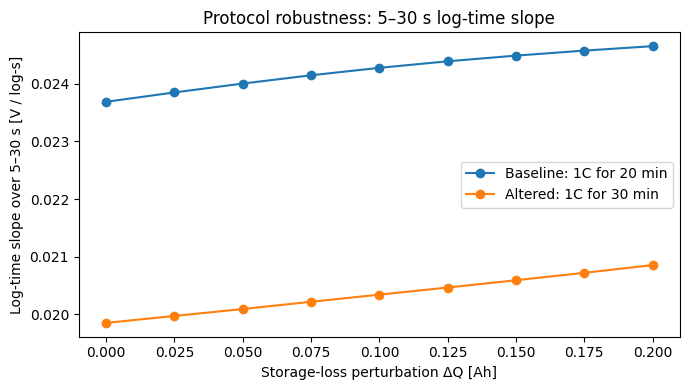

In [11]:
plt.figure(figsize=(7, 4))

sub_base = baseline_feature_df[baseline_feature_df["window_s"] == 30].copy()
sub_base = sub_base.sort_values("delta_q_ah")

sub_alt = altered_feature_df[altered_feature_df["window_s"] == 30].copy()
sub_alt = sub_alt.sort_values("delta_q_ah")

plt.plot(
    sub_base["delta_q_ah"],
    sub_base["log_time_slope_5_30_V_per_log_s"],
    marker="o",
    label="Baseline: 1C for 20 min"
)

plt.plot(
    sub_alt["delta_q_ah"],
    sub_alt["log_time_slope_5_30_V_per_log_s"],
    marker="o",
    label="Altered: 1C for 30 min"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Log-time slope over 5–30 s [V / log-s]")
plt.title("Protocol robustness: 5–30 s log-time slope")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
def run_dense_component_sweep(discharge_min, rest_min, protocol_name):
    rows = []

    experiment = make_experiment(discharge_min=discharge_min, rest_min=rest_min)

    for delta_q in dense_delta_q_levels:
        sim = pybamm.Simulation(
            make_model(),
            parameter_values=make_storage_loss_params(delta_q),
            experiment=experiment,
        )
        sol = sim.solve()

        comp = extract_component_rest_window(sol, 120)
        comp_df = pd.DataFrame(comp)

        row = component_summaries(comp_df)
        row["delta_q_ah"] = delta_q
        row["protocol"] = protocol_name
        rows.append(row)

    return pd.DataFrame(rows)

print("run_dense_component_sweep is now defined.")

run_dense_component_sweep is now defined.


In [14]:
baseline_component_df = run_dense_component_sweep(
    discharge_min=baseline_discharge_min,
    rest_min=rest_min,
    protocol_name="baseline_1C_20min"
)

altered_component_df = run_dense_component_sweep(
    discharge_min=altered_discharge_min,
    rest_min=rest_min,
    protocol_name="altered_1C_30min"
)

print("Baseline component rows:", len(baseline_component_df))
print("Altered component rows:", len(altered_component_df))

Baseline component rows: 9
Altered component rows: 9


In [15]:
baseline_component_df.to_csv("../outputs/protocol_baseline_component_sweep.csv", index=False)
altered_component_df.to_csv("../outputs/protocol_altered_component_sweep.csv", index=False)

print("Saved baseline and altered component sweep tables.")

Saved baseline and altered component sweep tables.


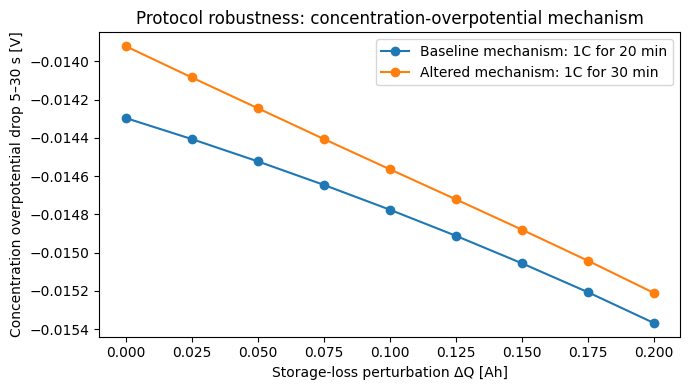

In [16]:
plt.figure(figsize=(7, 4))

base_comp = baseline_component_df.sort_values("delta_q_ah")
alt_comp = altered_component_df.sort_values("delta_q_ah")

plt.plot(
    base_comp["delta_q_ah"],
    base_comp["Concentration overpotential [V]__drop_5_30s"],
    marker="o",
    label="Baseline mechanism: 1C for 20 min"
)

plt.plot(
    alt_comp["delta_q_ah"],
    alt_comp["Concentration overpotential [V]__drop_5_30s"],
    marker="o",
    label="Altered mechanism: 1C for 30 min"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Concentration overpotential drop 5–30 s [V]")
plt.title("Protocol robustness: concentration-overpotential mechanism")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
baseline_feature_30 = baseline_feature_df[baseline_feature_df["window_s"] == 30].copy()
altered_feature_30 = altered_feature_df[altered_feature_df["window_s"] == 30].copy()

baseline_comparison_mech = pd.merge(
    baseline_feature_30[["delta_q_ah", "log_time_slope_5_30_V_per_log_s"]],
    baseline_component_df[["delta_q_ah", "Concentration overpotential [V]__drop_5_30s"]],
    on="delta_q_ah"
)

altered_comparison_mech = pd.merge(
    altered_feature_30[["delta_q_ah", "log_time_slope_5_30_V_per_log_s"]],
    altered_component_df[["delta_q_ah", "Concentration overpotential [V]__drop_5_30s"]],
    on="delta_q_ah"
)

baseline_comparison_mech["protocol"] = "baseline_1C_20min"
altered_comparison_mech["protocol"] = "altered_1C_30min"

baseline_comparison_mech.head(), altered_comparison_mech.head()

(   delta_q_ah  log_time_slope_5_30_V_per_log_s  \
 0       0.000                         0.023689   
 1       0.025                         0.023852   
 2       0.050                         0.024006   
 3       0.075                         0.024150   
 4       0.100                         0.024279   
 
    Concentration overpotential [V]__drop_5_30s           protocol  
 0                                    -0.014296  baseline_1C_20min  
 1                                    -0.014406  baseline_1C_20min  
 2                                    -0.014523  baseline_1C_20min  
 3                                    -0.014645  baseline_1C_20min  
 4                                    -0.014775  baseline_1C_20min  ,
    delta_q_ah  log_time_slope_5_30_V_per_log_s  \
 0       0.000                         0.019849   
 1       0.025                         0.019970   
 2       0.050                         0.020090   
 3       0.075                         0.020216   
 4       0.100        

In [18]:
print("Baseline correlation table")
display(baseline_comparison_mech.corr(numeric_only=True))

print("\nAltered correlation table")
display(altered_comparison_mech.corr(numeric_only=True))

Baseline correlation table


,delta_q_ah,log_time_slope_5_30_V_per_log_s,Concentration overpotential [V]__drop_5_30s
delta_q_ah,1.000000,0.992371,-0.998198
log_time_slope_5_30_V_per_log_s,0.992371,1.000000,-0.983200
Concentration overpotential [V]__drop_5_30s,-0.998198,-0.983200,1.000000



Altered correlation table


,delta_q_ah,log_time_slope_5_30_V_per_log_s,Concentration overpotential [V]__drop_5_30s
delta_q_ah,1.000000,0.999898,-0.999973
log_time_slope_5_30_V_per_log_s,0.999898,1.000000,-0.999920
Concentration overpotential [V]__drop_5_30s,-0.999973,-0.999920,1.000000


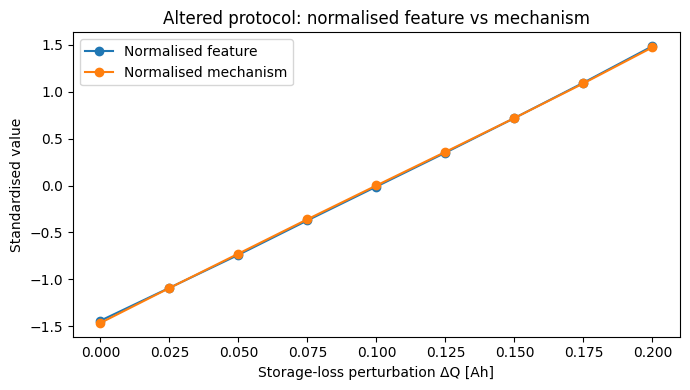

In [19]:
alt_plot_df = altered_comparison_mech.copy()

alt_plot_df["feature_norm"] = (
    alt_plot_df["log_time_slope_5_30_V_per_log_s"] - alt_plot_df["log_time_slope_5_30_V_per_log_s"].mean()
) / alt_plot_df["log_time_slope_5_30_V_per_log_s"].std()

alt_plot_df["mechanism_norm"] = (
    (-alt_plot_df["Concentration overpotential [V]__drop_5_30s"]) - (-alt_plot_df["Concentration overpotential [V]__drop_5_30s"]).mean()
) / (-alt_plot_df["Concentration overpotential [V]__drop_5_30s"]).std()

plt.figure(figsize=(7, 4))
plt.plot(
    alt_plot_df["delta_q_ah"],
    alt_plot_df["feature_norm"],
    marker="o",
    label="Normalised feature"
)
plt.plot(
    alt_plot_df["delta_q_ah"],
    alt_plot_df["mechanism_norm"],
    marker="o",
    label="Normalised mechanism"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Standardised value")
plt.title("Altered protocol: normalised feature vs mechanism")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
baseline_comparison_mech.to_csv("../outputs/protocol_baseline_feature_vs_mechanism.csv", index=False)
altered_comparison_mech.to_csv("../outputs/protocol_altered_feature_vs_mechanism.csv", index=False)

print("Saved baseline and altered feature-vs-mechanism comparison tables.")

Saved baseline and altered feature-vs-mechanism comparison tables.
